## Une as duas tabelas

In [1]:
import pandas as pd

# Ler os arquivos CSV
articles_df = pd.read_csv('articles.csv')
data_extraction_df = pd.read_csv('data_extraction.csv')

# Renomear colunas para facilitar o merge
data_extraction_df = data_extraction_df.rename(columns={'article': 'title'})

# Converter colunas de data para datetime (se necessário)
articles_df['year'] = pd.to_numeric(articles_df['year'], errors='coerce')
data_extraction_df['Ano'] = pd.to_numeric(data_extraction_df['Ano'], errors='coerce')

# Fazer o merge dos dataframes
merged_df = pd.merge(
    articles_df[['title', 'year']],  # Colunas que queremos do articles.csv
    data_extraction_df,
    on='title',
    how='outer'
)

# Preencher anos faltantes: usar o ano do data_extraction quando não houver no articles
merged_df['year'] = merged_df['year'].fillna(merged_df['Ano'])

# Remover a coluna Ano auxiliar
merged_df = merged_df.drop(columns=['Ano'])

# Renomear coluna year para ano para manter consistência
merged_df = merged_df.rename(columns={'year': 'ano'})

# Reordenar colunas (opcional)
cols = ['title', 'ano'] + [col for col in merged_df.columns if col not in ['title', 'ano']]
merged_df = merged_df[cols]

# Salvar o resultado em um novo arquivo CSV
merged_df.to_csv('merged_articles_data.csv', index=False)

print("Arquivo 'merged_articles_data.csv' criado com sucesso!")
print(f"Total de registros: {len(merged_df)}")

ModuleNotFoundError: No module named 'pandas'

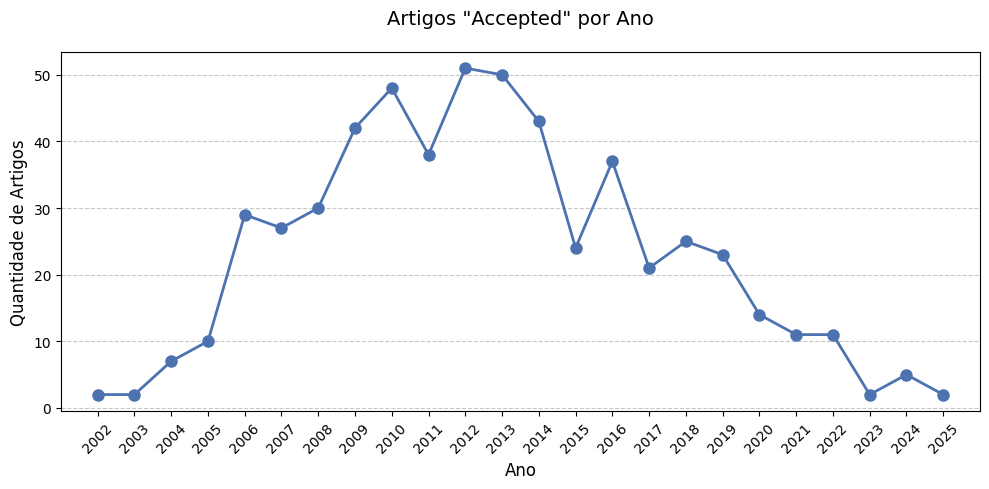

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
articles_df = pd.read_csv('articles.csv')

# Filtrar apenas artigos "Accepted" e contar por ano
accepted_per_year = articles_df[articles_df['status'] == 'Accepted']['year'].value_counts().sort_index()

# Configurar o gráfico
plt.figure(figsize=(10, 5))
accepted_per_year.plot(
    marker='o',
    linestyle='-',
    color='#4C72B0',
    linewidth=2,
    markersize=8
)

# Adicionar rótulos e título
plt.title('Artigos "Accepted" por Ano', fontsize=14, pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Artigos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar eixos para mostrar apenas anos com dados
plt.xticks(accepted_per_year.index, rotation=45)
plt.xlim(accepted_per_year.index.min() - 1, accepted_per_year.index.max() + 1)

plt.tight_layout()
plt.savefig('accepted_per_year.png', dpi=300)
plt.show()

<Figure size 1200x600 with 0 Axes>

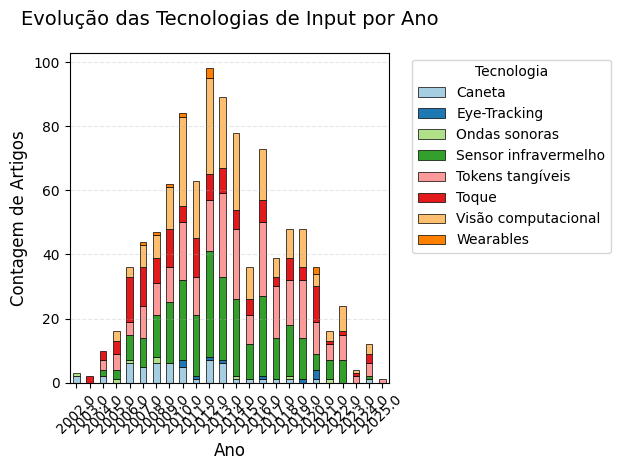

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar e preparar os dados
data_extraction_df = pd.read_csv('data_extraction.csv')

# Expandir múltiplas tecnologias de input (separadas por vírgula)
input_tech = data_extraction_df['Tecnologia do input'].str.get_dummies(sep=', ')

# Combinar com o ano e agregar
tech_by_year = pd.concat([data_extraction_df['Ano'], input_tech], axis=1)
tech_by_year = tech_by_year.groupby('Ano').sum()

# Configurar cores
colors = plt.cm.Paired(range(len(tech_by_year.columns)))

# Plotar
plt.figure(figsize=(12, 6))
tech_by_year.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Ajustes estéticos
plt.title('Evolução das Tecnologias de Input por Ano', fontsize=14, pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Contagem de Artigos', fontsize=12)
plt.legend(
    title='Tecnologia',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('input_tech_by_year.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd

# Dicionário de traduções
translation_dict = {
    # Tecnologias de Display
    'Embutido': 'Embedded',
    'Projetor superior': 'Front-Projected',
    'Projetor inferior': 'Rear-Projected',

    # Tecnologias de Input
    'Caneta': 'Pen',
    'Ondas sonoras': 'Sound-Based',
    'Sensor infravermelho': 'Sensor-Assisted-Vision-Based',
    'Tokens tangíveis': 'Tangible-Tokens',
    'Toque': 'Electrical-Based',
    'Visão computacional': 'Vision-Based'
}

def translate_terms(text):
    if pd.isna(text):
        return text
    for pt, en in translation_dict.items():
        text = text.replace(pt, en)
    return text

# Carregar os dados (substitua pelo seu arquivo real)
df = pd.read_csv('data_extraction.csv')

# Aplicar traduções nas colunas relevantes
df['Tecnologia do display'] = df['Tecnologia do display'].apply(translate_terms)
df['Tecnologia do input'] = df['Tecnologia do input'].apply(translate_terms)

# Salvar o resultado (substitua pelo nome desejado)
df.to_csv('transformed_data.csv', index=False)

print("Transformação concluída! Resultado salvo em 'transformed_data.csv'")
print("\nAmostra dos dados transformados:")
print(df.head())